# Results

## Librairies

In [1]:
import os
import ast

import re
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## Read results

In [120]:
results_folder = "."
file_name = f"results_0_all_testsubset_[1]_p=0.95_nlp.csv"

In [121]:
match = re.search(r"results_(\d+).*?\[(\d+)\]_p=([\d.]+)", file_name)
if match:
    c = int(match.group(2))  # 1
    p = float(match.group(3))           # 0.7
c, p

(1, 0.95)

In [122]:
results_df = pd.read_csv(file_name)
results_df = results_df.sort_values(by="error_polytope")

In [123]:
results_df

,error_x0_a,error_x0_b,error_x0_c,error_polytope,net_prob_x0,net_class_x0,net_approx_prob_x0,net_approx_class_x0,net_prob_x_opt,net_class_x_opt,net_logits_x_opt,net_approx_prob_x_opt,net_approx_class_x_opt,net_approx_logits_x_opt
56,1.800000e-07,1.800000e-07,1.800000e-07,1.800000e-07,1.000000,1,1.000000,1,1.000000,1,"[5.739143083922839e-17, 0.9999999938443394, 9....",1.000000,1,"[3.09002509613203e-20, 0.9999999997529958, 6.6..."
467,2.600000e-07,2.600000e-07,2.600000e-07,2.600000e-07,1.000000,1,1.000000,1,1.000000,1,"[1.254659786877992e-15, 0.9999999891711319, 3....",1.000000,1,"[7.741112684886258e-18, 0.9999999908128704, 1...."
430,2.700000e-07,2.700000e-07,2.700000e-07,2.700000e-07,1.000000,1,1.000000,1,1.000000,1,"[2.0627295219267558e-17, 0.9999999884177139, 1...",1.000000,1,"[1.3675563369702391e-19, 0.9999999918040378, 3..."
648,2.900000e-07,2.900000e-07,2.900000e-07,2.900000e-07,1.000000,1,1.000000,1,1.000000,1,"[7.413332101223156e-16, 0.9999999887537646, 5....",1.000000,1,"[2.539684793297886e-18, 0.9999999992526631, 1...."
428,3.000000e-07,3.000000e-07,3.000000e-07,3.000000e-07,1.000000,1,1.000000,1,1.000000,1,"[1.4081318031725421e-15, 0.9999999883768148, 8...",1.000000,1,"[8.802637376883336e-19, 0.9999999995391442, 3...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556,3.101800e-04,3.101800e-04,3.101800e-04,3.132586e+01,0.999982,1,0.999999,1,0.994822,1,"[3.18379656945995e-06, 0.9948215757463765, 0.0...",0.999960,1,"[3.3184859984735955e-11, 0.9999597965840109, 2..."
915,8.347000e-04,8.347000e-04,8.347000e-04,3.155954e+01,0.999948,1,0.999999,1,0.995418,8,"[2.212783363264783e-08, 0.004337763913480461, ...",0.999847,1,"[3.4305208611873644e-09, 0.9998466170032575, 1..."
113,2.445600e-04,2.445600e-04,2.445600e-04,3.165052e+01,0.999986,1,0.999998,1,0.988610,1,"[8.736881835071306e-09, 0.9886096419118032, 2....",0.999868,1,"[3.652595567615956e-14, 0.9998676000817515, 1...."
244,4.410300e-03,4.410300e-03,4.410300e-03,3.165523e+01,0.999551,1,0.999919,1,0.961697,1,"[3.7009364769683655e-10, 0.9616973557212255, 0...",0.999998,1,"[3.799482654314867e-14, 0.9999979119338405, 9...."


In [124]:
results_df.columns

Index(['error_x0_a', 'error_x0_b', 'error_x0_c', 'error_polytope',
       'net_prob_x0', 'net_class_x0', 'net_approx_prob_x0',
       'net_approx_class_x0', 'net_prob_x_opt', 'net_class_x_opt',
       'net_logits_x_opt', 'net_approx_prob_x_opt', 'net_approx_class_x_opt',
       'net_approx_logits_x_opt'],
      dtype='object')

In [125]:
# sanity check
tolerance = 1e-6

mask_1 = ((results_df['error_x0_a'] - results_df['error_x0_b']).abs() < tolerance).all()
mask_2 = ((results_df['error_x0_b'] - results_df['error_x0_c']).abs() < tolerance).all()
mask_3 = ((results_df['error_x0_c'] - results_df['error_x0_a']).abs() < tolerance).all()

mask = (mask_1 and mask_2 and mask_3).item()

mask

True

## Filter data

### Remove non-converging samples

In [126]:
errors_samples = results_df['error_x0_a']
errors_polytopes = results_df['error_polytope']

mask_1 = np.abs(errors_samples - errors_polytopes) < 1e-5
indices_1 = mask_1[mask_1].index
results_df = results_df.drop(indices_1)

print(f"There are {len(indices_1)} non-converging samples at indices:\n{list(indices_1)}")

There are 286 non-converging samples at indices:
[56, 467, 430, 648, 428, 478, 944, 272, 302, 150, 156, 78, 379, 91, 334, 77, 97, 101, 390, 541, 665, 1017, 398, 162, 350, 539, 691, 14, 1013, 660, 654, 550, 690, 939, 363, 559, 161, 72, 692, 291, 455, 503, 301, 195, 597, 605, 962, 184, 120, 651, 515, 990, 526, 296, 409, 484, 875, 74, 506, 40, 908, 299, 39, 942, 1036, 600, 214, 427, 612, 384, 1018, 364, 626, 305, 766, 277, 355, 133, 115, 659, 500, 250, 761, 46, 405, 604, 311, 136, 499, 627, 263, 1070, 1100, 418, 774, 644, 275, 706, 7, 449, 117, 70, 1097, 631, 471, 649, 1098, 135, 561, 979, 346, 719, 279, 1061, 202, 700, 45, 1035, 842, 525, 1087, 676, 1044, 955, 50, 109, 964, 127, 265, 760, 73, 1008, 812, 322, 741, 57, 1069, 674, 882, 469, 44, 415, 792, 206, 827, 686, 385, 771, 429, 1041, 493, 285, 977, 928, 805, 1034, 118, 166, 1014, 910, 642, 935, 261, 524, 1075, 267, 330, 985, 646, 303, 173, 387, 1101, 535, 210, 481, 424, 918, 916, 746, 69, 834, 623, 744, 149, 254, 1023, 340, 832, 852, 

### Remove ill-predicted samples

We remove sample satisfying at least one of the following conditions:
- $x_0$ is wrongly predicted by N or
- $x_0$ is correctly predicted by N but with probability ≤ p or
- $x_0$ is correctly predicted by N but $x_{opt}$ is not

In [127]:
mask_2a = (results_df['net_class_x0'] != c)    # x_0 wrongly predicted
mask_2c = (results_df['net_prob_x0'] <= p)                  # x_0 correctly predicted but with prob ≤ p
mask_2b = (results_df['net_class_x_opt'] != c) # x_opt wrongly predicted
mask_2 = mask_2a | mask_2b | mask_2c
indices_2 = mask_2[mask_2].index
results_df = results_df.drop(indices_2)

print(f"There are {len(indices_2)} samples that are ill-predicted by N at indices:\n{list(indices_2)}")

There are 332 samples that are ill-predicted by N at indices:
[37, 681, 1073, 963, 54, 179, 840, 810, 1060, 868, 1038, 560, 134, 1076, 1019, 487, 1091, 897, 283, 713, 923, 1058, 862, 148, 328, 750, 264, 887, 571, 680, 598, 732, 683, 599, 1067, 885, 809, 545, 637, 1054, 831, 1015, 498, 1074, 62, 327, 1030, 382, 203, 707, 993, 276, 586, 492, 729, 734, 488, 1048, 205, 485, 575, 594, 869, 890, 534, 777, 926, 96, 803, 309, 878, 337, 88, 20, 170, 709, 738, 76, 983, 753, 48, 121, 973, 269, 189, 854, 106, 104, 656, 933, 668, 971, 287, 947, 580, 756, 718, 15, 32, 344, 246, 1046, 268, 790, 207, 688, 325, 884, 2, 444, 1071, 228, 968, 891, 445, 883, 959, 479, 931, 745, 902, 343, 578, 155, 527, 1029, 776, 361, 1082, 986, 87, 348, 813, 1040, 1090, 714, 530, 242, 457, 857, 26, 19, 1059, 703, 4, 517, 1033, 762, 937, 828, 131, 673, 848, 621, 313, 41, 212, 611, 701, 1004, 767, 365, 806, 863, 511, 991, 98, 989, 888, 436, 306, 217, 880, 331, 861, 341, 865, 912, 1024, 395, 219, 61, 298, 1011, 529, 531, 158

In [128]:
# sanity checks
print(
    results_df.shape[0],
    np.sum(results_df.net_prob_x0 >= p).item(),
    np.sum(results_df.net_class_x0 == 1).item(),
    np.sum(results_df.net_class_x_opt == 1).item()
)

487 487 487 487


In [129]:
preds_approx = results_df['net_approx_class_x0']

mask_3 = preds_approx != (np.ones(shape=(results_df.shape[0])) * c)
indices_3 = mask_3[mask_3].index

print(f"There are {len(indices_3)} samples wrongly predicted by Ñ at indices:\n{list(indices_3)}")

There are 1 samples wrongly predicted by Ñ at indices:
[789]


In [130]:
results_df.loc[indices_3]

,error_x0_a,error_x0_b,error_x0_c,error_polytope,net_prob_x0,net_class_x0,net_approx_prob_x0,net_approx_class_x0,net_prob_x_opt,net_class_x_opt,net_logits_x_opt,net_approx_prob_x_opt,net_approx_class_x_opt,net_approx_logits_x_opt
789,1.045639,1.045639,1.045639,27.134671,0.987046,1,0.651047,2,0.815713,1,"[3.9988334758819223e-10, 0.8157129976918165, 0...",0.999909,2,"[2.6104647464370676e-13, 2.0320667665712465e-0..."


## Results

### Errors at x0 and x_opt

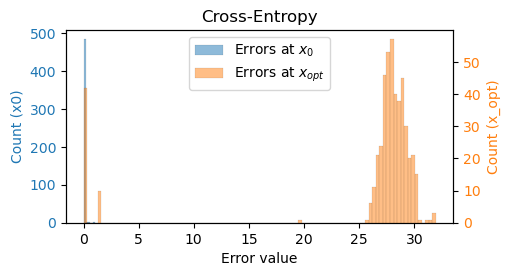

In [131]:
errors_x0 = list(results_df.error_x0_a.values)
errors_x_opt = list(results_df.error_polytope.values)

fig, ax1 = plt.subplots(figsize=(5, 2.5))
ax2 = ax1.twinx()  # second y-axis

# first histogram on ax1
ax1.hist(errors_x0, bins=5, alpha=0.5, edgecolor="black", linewidth=0.1, color="C0", label=r"Errors at $x_0$")
ax1.set_ylabel("Count (x0)", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")

# second histogram on ax2
ax2.hist(errors_x_opt, bins=100, alpha=0.5, edgecolor="black", linewidth=0.1, color="C1", label=r"Errors at $x_{opt}$")
ax2.set_ylabel("Count (x_opt)", color="C1")
ax2.tick_params(axis="y", labelcolor="C1")

# shared x-axis
ax1.set_xlabel("Error value")
plt.title(r"Cross-Entropy")

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center")
plt.savefig(f"erors_c={c}_p={p}.pdf", bbox_inches="tight")
plt.show()

### Misclassified polytopes

In [132]:
# We detect Ñ(x_opt) ≠ N(x_opt)
net_class_x_opt = results_df.net_class_x_opt
net_approx_class_x_opt = results_df.net_approx_class_x_opt

mis_idx = np.where(net_class_x_opt != net_approx_class_x_opt)[0]

print(f"There are {len(mis_idx)} misclassified polytopes at indices:\n{mis_idx}")

There are 15 misclassified polytopes at indices:
[ 52  60  61  62  68  86 109 114 143 195 243 255 258 276 361]


In [133]:
mis_df = results_df.iloc[mis_idx]

In [136]:
# mis_df

15 15 15 15


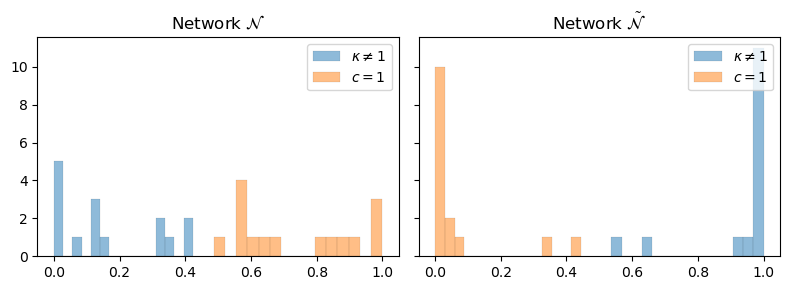

In [139]:
net_logits_x_opt = mis_df.net_logits_x_opt.apply(ast.literal_eval)
net_logits_x_opt = list(net_logits_x_opt.values)

net_class_x_opt = mis_df.net_class_x_opt
net_class_x_opt = list(map(int, net_class_x_opt))
# net_class_x_opt = list(net_class_x_opt.values)

net_approx_logits_x_opt = mis_df.net_approx_logits_x_opt.apply(ast.literal_eval)
net_approx_logits_x_opt = list(net_approx_logits_x_opt.values)

net_approx_class_x_opt =  mis_df.net_approx_class_x_opt
net_approx_class_x_opt = list(map(int, net_approx_class_x_opt))
#net_approx_class_x_opt = list(net_approx_class_x_opt.values)

# sanity check
assert (net_class_x_opt != net_approx_class_x_opt) == True

net_probs_c = [logits[c] for logits, c in zip(net_logits_x_opt, net_class_x_opt)]
net_probs_kappa = [logits[k] for logits, k in zip(net_logits_x_opt, net_approx_class_x_opt)]

net_approx_probs_c = [logits[c] for logits, c in zip(net_approx_logits_x_opt, net_class_x_opt)]
net_approx_probs_kappa = [logits[k] for logits, k in zip(net_approx_logits_x_opt, net_approx_class_x_opt)]

print(
    len(net_probs_c),
    len(net_probs_c),
    len(net_approx_probs_c),
    len(net_approx_probs_kappa)
    )

bins = len(net_probs_c)

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)  # 1 row, 2 cols

# --- Left plot ---
axes[0].set_title(r"Network $\mathcal{N}$")
axes[0].hist(net_probs_kappa, bins=bins, label=rf"$\kappa \neq {c}$", alpha=0.5, edgecolor="black", linewidth=0.1)
axes[0].hist(net_probs_c, bins=bins, label=rf"$c={c}$", alpha=0.5, edgecolor="black", linewidth=0.1)
axes[0].legend(loc="upper right")

# --- Right plot ---
axes[1].set_title(r"Network $\mathcal{\tilde N}$")
axes[1].hist(net_approx_probs_kappa, bins=bins, label=rf"$\kappa \neq {c}$", alpha=0.5, edgecolor="black", linewidth=0.1)
axes[1].hist(net_approx_probs_c, bins=bins, label=rf"$c={c}$", alpha=0.5, edgecolor="black", linewidth=0.1)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(f"misclassified_polytopes_c={c}_p={p}.pdf", bbox_inches="tight")
plt.show()


In [119]:
net_class_x_opt, net_approx_class_x_opt

([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
 [2, 7, 4, 2, 2, 7, 2, 2, 7, 7, 2, 7, 6, 7])

### Draft...

**Same sample and polytope errors**

- In these cases, the solver fails to converge and keeps the original solution as the optimal one

In [164]:
mask_pb_1

24     True
55     True
75     True
81     True
89     True
       ... 
948    True
963    True
965    True
978    True
979    True
Length: 98, dtype: bool

In [158]:
# sanity check
tol = 1e-6

mask_pb_1 = ((results_pb_df['error_1'] - results_pb_df['error_polytope']).abs() < tol)
indices_pb_1 = mask_pb_1[mask_pb_1].index

print(f"There are {len(indices_pb_1)}/{len(indices_pb)} problematic samples for which the solver failed to converge.")
print(f"In these cases, the sample and polytope errors are the same (up to tolerance {tol}):")

indices_pb_1

There are 98/98 problematic samples for which the solver failed to converge.
In these cases, the sample and polytope errors are the same (up to tolerance 1e-06):


Index([ 24,  55,  75,  81,  89, 101, 115, 129, 146, 150, 159, 161, 184, 192,
       195, 255, 257, 265, 272, 277, 283, 301, 308, 313, 326, 329, 342, 350,
       354, 365, 374, 389, 395, 398, 400, 417, 423, 430, 435, 450, 452, 460,
       468, 502, 503, 504, 507, 508, 514, 519, 538, 545, 558, 575, 583, 592,
       596, 599, 624, 628, 630, 657, 661, 664, 683, 686, 690, 691, 694, 711,
       716, 728, 729, 740, 754, 756, 760, 777, 779, 786, 790, 794, 798, 804,
       831, 832, 833, 872, 879, 882, 909, 915, 932, 948, 963, 965, 978, 979],
      dtype='int64')

In [160]:
results_pb_1_df = results_df.loc[indices_pb_1]
results_pb_1_df.head()

,error_1,error_2,error_3,error_polytope
24,1.290000e-06,1.290000e-06,1.290000e-06,1.285110e-06
55,6.100000e-07,6.100000e-07,6.100000e-07,6.079106e-07
75,1.000000e-08,1.000000e-08,1.000000e-08,8.572733e-09
81,2.000000e-08,2.000000e-08,2.000000e-08,1.698141e-08
89,1.130000e-06,1.130000e-06,1.130000e-06,1.128830e-06


**Small polytopes errors**

In [170]:
# sanity check

mask_pb_2 = ~mask_pb_1
indices_pb_2 = mask_pb_2[mask_pb_2].index

print(f"There are {len(indices_pb_2)}/{len(indices_pb)} problematic samples with inconsistent polytope error.")
print(f"In these cases, the sample errors are much larger than the polytope errors (impossible):")

indices_pb_2

There are 0/98 problematic samples with inconsistent polytope error.
In these cases, the sample errors are much larger than the polytope errors (impossible):


Index([], dtype='int64')

In [171]:
results_pb_2_df = results_df.loc[indices_pb_2]
results_pb_2_df

,error_1,error_2,error_3,error_polytope


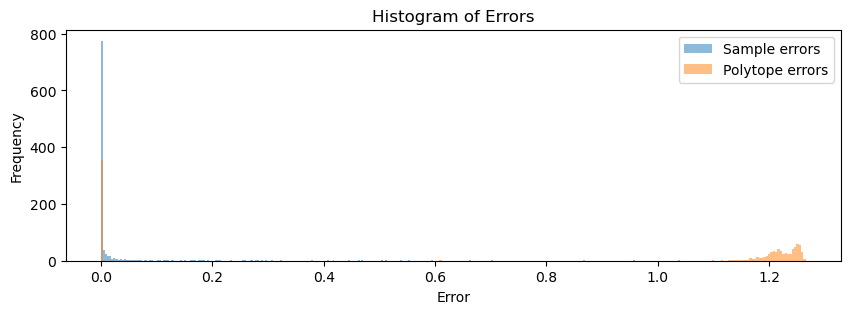

In [156]:
plt.figure(figsize=(10,3))
plt.hist(results_df['error_1'], bins=300, alpha=0.5, label='Sample errors')
plt.hist(results_df['error_polytope'], bins=300, alpha=0.5, label='Polytope errors')

plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Histogram of Errors')
plt.legend()
# plt.grid(True)
plt.show()
